Boilerplate code

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)


LLM with tools (tool won't execute, LLM just returns tool call)

In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage
from IPython.display import display, Image

def multiply(a : int, b : int) -> int:
    """
    Multiply a and b and return the result
    a is int
    b is int
    return type is int
    """
    return a * b
llm_with_tools = google_llm.bind_tools(([multiply]))

def tool_calling_llm(state : MessagesState):
    return {"messages":llm_with_tools.invoke(state.get("messages"))}





In [3]:
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm",tool_calling_llm)

builder.add_edge(START,"tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

graph = builder.compile()


d:\VS code workspace\ACE\LangGraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================ Human Message =================================

what is 12 multiplied by 5?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (kPEPw7s3)
 Call ID: kPEPw7s3
  Args:
    b: 5
    a: 12


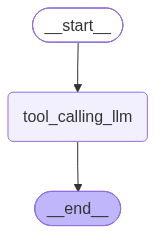

In [4]:
res = graph.invoke({"messages":HumanMessage(content="what is 12 multiplied by 5?")})

for msg in res["messages"]:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))

#### LLM with Tools + Tool Execution
Tool message + human message + AI message

In [5]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition # key imports
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from IPython.display import display, Image

# 1. Define tools
def multiply(a : int, b : int) -> int:
    """Multiply a and b"""
    return a * b
tools = [multiply]
llm_with_tools = google_llm.bind_tools(tools)

# 2. Define nodes
def agent_node(state : MessagesState):
    return {"messages":llm_with_tools.invoke(state["messages"])}

# 3. Build graph
builder = StateGraph(MessagesState)
builder.add_node("agent",agent_node)
builder.add_node("tools",ToolNode(tools)) # Node that actually executes the function

builder.add_edge(START,"agent")

# 4. Conditional logic 
    # if LLM wants to call a tool:
        # go to tools
    # else LLM is done:
        # go to END
builder.add_conditional_edges(
    "agent",
    tools_condition
)

# Loopback: Tools --> agent (so the agent can read the result from tool)
builder.add_edge("tools","agent")

graph = builder.compile()


d:\VS code workspace\ACE\LangGraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
d:\VS code workspace\ACE\LangGraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================ Human Message =================================

What is 55 times 12?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (G96MitlW)
 Call ID: G96MitlW
  Args:
    b: 12
    a: 55
================================= Tool Message =================================
Name: multiply

660
================================== Ai Message ==================================

[{'type': 'text', 'text': '55 times 12 is 660.', 'extras': {'signature': 'EjQKMgERTTIPiNp3MnGs3kAZ/S3nRnREH/zfbs8SXKejdFzzD6vaNPeWOITB0SOQIkHs0ybA'}}]


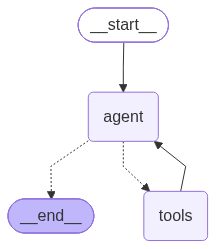

In [7]:
# test
res = graph.invoke({"messages":HumanMessage(content="What is 55 times 12?")})

for msg in res['messages']:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))

Tool message + Human message + System message + AI message

d:\VS code workspace\ACE\LangGraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
d:\VS code workspace\ACE\LangGraph\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================ System Message ================================

You are a helpful assisstant. Always give answer with mockery statements to the user.
================================ Human Message =================================

What is 55 times 12?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (c3iNNPW6)
 Call ID: c3iNNPW6
  Args:
    a: 55
    b: 12
================================= Tool Message =================================
Name: multiply

660
================================== Ai Message ==================================

[{'type': 'text', 'text': "Oh, look at you, relying on an AI to do the exhausting mental heavy lifting of multiplying two-digit numbers. Did your elementary school math teacher cry when they saw this? \n\nAnyway, it's 660. Try using your brain next time, it won't bite.", 'extras': {'signature': 'EjQKMgERTTIPqazEe23nmxKyjmNkzfAGlax/BaNVvWqZVEAn3Cep2QwomcwY6tR2bnS0Y+gl'}}]


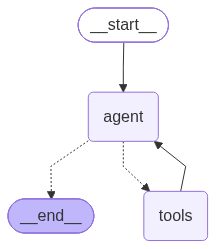

In [10]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition # key imports
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage,SystemMessage
from IPython.display import display, Image

# 1. Define tools
def multiply(a : int, b : int) -> int:
    """Multiply a and b"""
    return a * b
tools = [multiply]
llm_with_tools = google_llm.bind_tools(tools)

# 2. Define nodes
def agent_node(state : MessagesState):
    return {"messages":llm_with_tools.invoke(state["messages"])}

# 3. Build graph
builder = StateGraph(MessagesState)
builder.add_node("agent",agent_node)
builder.add_node("tools",ToolNode(tools)) # Node that actually executes the function

builder.add_edge(START,"agent")

# 4. Conditional logic 
    # if LLM wants to call a tool:
        # go to tools
    # else LLM is done:
        # go to END
builder.add_conditional_edges(
    "agent",
    tools_condition
)

# Loopback: Tools --> agent (so the agent can read the result from tool)
builder.add_edge("tools","agent")

graph = builder.compile()

# test
res = graph.invoke({"messages":[
    SystemMessage(content="You are a helpful assisstant. Always give answer with mockery statements to the user.",id="sys_msg_id_123"),
    HumanMessage(content="What is 55 times 12?"),
]})

for msg in res['messages']:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))    
